Goal: Implement Experiment 1 and 2 with related plots

# All the required libraries

In [5]:
import os
import json
import random
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm import tqdm as _tqdm
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import re, math
from scipy.stats import wilcoxon
import glob, itertools
from sklearn.metrics import precision_recall_curve, roc_curve, auc, average_precision_score
import seaborn as sns
from scipy.stats import ttest_rel

# Functions used for both experiments

In [ ]:
# Config (defaults)
DEFAULT_SEEDS = [0,42,123]
DEFAULT_EPOCHS = 50
DEFAULT_BATCH_SIZE = 64
DEFAULT_LR = 1e-3
DEFAULT_WEIGHT_DECAY = 1e-4
DEFAULT_OPTIM = "adamw"  # or "sgd"
DEFAULT_NUM_WORKERS = 0
DEFAULT_IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# Utilities
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False


def discover_pipelines_with_folds(pipeline_roots: List[Path]) -> Dict[str, List[Path]]:
    """Each pipeline root must contain a `folds/` dir with fold_* subfolders.
    Returns mapping: pipeline_name -> list of fold paths.
    """
    mapping = {}
    for root in pipeline_roots:
        root = Path(root)
        name = root.name
        folds_dir = root / "folds"
        if not folds_dir.exists():
            raise FileNotFoundError(f"{root} must contain a 'folds/' directory")
        folds = [d for d in sorted(folds_dir.iterdir()) if d.is_dir() and d.name.startswith("fold_")]
        if not folds:
            raise FileNotFoundError(f"No fold_* directories found under {folds_dir}")
        mapping[name] = folds
    # sanity: identical fold counts helpful for paired stats
    lengths = {len(v) for v in mapping.values()}
    if len(lengths) != 1:
        print("[WARN] Pipelines have different number of folds; paired stats will use intersections only.")
    return mapping


@dataclass
class RunConfig:
    pipeline: str
    fold_name: str
    seed: int
    epochs: int = DEFAULT_EPOCHS
    batch_size: int = DEFAULT_BATCH_SIZE
    lr: float = DEFAULT_LR
    weight_decay: float = DEFAULT_WEIGHT_DECAY
    optim: str = DEFAULT_OPTIM
    num_workers: int = DEFAULT_NUM_WORKERS
    img_size: int = DEFAULT_IMG_SIZE


# Data & Dataloaders

def build_transforms(img_size: int):
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02)], p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return train_tf, eval_tf


def build_dataloaders_fold(fold_path: Path, img_size: int, batch_size: int, num_workers: int, seed: int):
    """Expects within fold_path: train/, train_masks/, val/, val_masks/ with class subfolders.
    Uses train/ for training and val/ for evaluation.
    Ignores *mask directories for training here (they were used in preprocessing stage).
    """
    train_dir = fold_path / "train"
    val_dir = fold_path / "val"
    if not train_dir.exists() or not val_dir.exists():
        raise FileNotFoundError(f"Missing train/ or val/ under {fold_path}")

    train_tf, eval_tf = build_transforms(img_size)
    train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
    val_ds = datasets.ImageFolder(val_dir, transform=eval_tf)

    class_names = train_ds.classes


    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True) 
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    

    return train_loader, val_loader, class_names




# Model & Training

def build_model(num_classes: int) -> nn.Module:
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def get_optimizer(model: nn.Module, lr: float, wd: float, name: str):
    params = [p for p in model.parameters() if p.requires_grad]
    if name.lower() == "sgd":
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=wd, nesterov=True)
    elif name.lower() == "adamw":
        return optim.AdamW(params, lr=lr, weight_decay=wd)
    else:
        raise ValueError(f"Unknown optimizer: {name}")


def train_one_epoch(model, loader, device, criterion, optimizer):
    model.train()
    losses = []
    correct = 0
    total = 0
    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        with torch.no_grad():
            preds = logits.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    return float(np.mean(losses)), correct / max(1, total)


def evaluate(model, loader, device, criterion, class_names: List[str]):
    model.eval()
    losses = []
    all_targets, all_probs, all_preds = [], [], []
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, targets)
            losses.append(loss.item())
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            all_targets.append(targets.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    metrics = {
        "loss": float(np.mean(losses)),
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
    }

    # Binary extras (defective vs good); detect positive index for 'defective'
    if len(class_names) == 2:
        try:
            pos_idx = class_names.index("defective")
        except ValueError:
            pos_idx = 1  # fallback to class 1
        try:
            # auroc = roc_auc_score(y_true, y_prob[:, pos_idx])
            auroc = roc_auc_score((y_true == pos_idx).astype(int), y_prob[:, pos_idx])
        except ValueError:
            auroc = np.nan
        try:
            auprc = average_precision_score(y_true == pos_idx, y_prob[:, pos_idx])
        except ValueError:
            auprc = np.nan
        prec, rec, f1, _ = precision_recall_fscore_support(y_true == pos_idx, y_pred == pos_idx, average="binary", zero_division=0)
        cm = confusion_matrix(y_true, y_pred, labels=[1-pos_idx, pos_idx])  # [[tn,fp],[fn,tp]] if labels ordered accordingly
        metrics.update({
            "auroc": float(auroc),
            "auprc": float(auprc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "tn": int(cm[0,0]) if cm.shape==(2,2) else np.nan,
            "fp": int(cm[0,1]) if cm.shape==(2,2) else np.nan,
            "fn": int(cm[1,0]) if cm.shape==(2,2) else np.nan,
            "tp": int(cm[1,1]) if cm.shape==(2,2) else np.nan,
        })

    return metrics, y_true, y_pred, y_prob



# Notebook training loop with tqdm

def run_training_notebook(pipeline_roots: List[str], out_dir: str,
                          seeds: List[int] = DEFAULT_SEEDS, device: Optional[str] = None,
                          epochs: int = DEFAULT_EPOCHS, batch_size: int = DEFAULT_BATCH_SIZE,
                          lr: float = DEFAULT_LR, weight_decay: float = DEFAULT_WEIGHT_DECAY,
                          optim_name: str = DEFAULT_OPTIM, num_workers: int = DEFAULT_NUM_WORKERS,
                          img_size: int = DEFAULT_IMG_SIZE):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    out_dir = Path(out_dir);
    out_dir.mkdir(parents=True, exist_ok=True)

    pipelines = discover_pipelines_with_folds([Path(p) for p in pipeline_roots])

    all_runs = []
    for pipeline, fold_paths in tqdm(pipelines.items(), desc="Pipelines"):
        for fold_path in tqdm(fold_paths, desc=f"Folds: {pipeline}", leave=False):
            fold_name = fold_path.name
            for seed in tqdm(seeds, desc="Seeds", leave=False):
                set_seed(seed)
                run_cfg = RunConfig(pipeline, fold_name, seed, epochs, batch_size, lr, weight_decay, optim_name, num_workers, img_size)
                run_dir = out_dir / pipeline / fold_name / f"seed{seed}"
                (run_dir / "artifacts").mkdir(parents=True, exist_ok=True)

                with open(run_dir / "run_config.json", "w") as f:
                    json.dump(asdict(run_cfg), f, indent=2)

                # Data
                train_loader, val_loader, class_names = build_dataloaders_fold(
                    fold_path, img_size, batch_size, num_workers, seed
                )
                num_classes = len(class_names)

                # Save class mapping for transparency
                class_mapping = {
                    "class_names": class_names,
                    "positive_class": "defective" if "defective" in class_names else class_names[-1],
                    "pos_idx": int(class_names.index("defective")) if "defective" in class_names else 1
                }
                with open(run_dir / "class_mapping.json", "w") as f:
                    json.dump(class_mapping, f, indent=2)


                # Class weights (from training set) for imbalance
                train_targets = []
                for _, targets in train_loader:
                    train_targets.extend(targets.numpy().tolist())
                class_counts = np.bincount(train_targets, minlength=num_classes)
                class_weights = class_counts.max() / np.clip(class_counts, 1, None)
                class_weights_t = torch.tensor(class_weights, dtype=torch.float32)

                # Model
                model = build_model(num_classes).to(device)
                criterion = nn.CrossEntropyLoss(weight=class_weights_t.to(device))
                optimizer = get_optimizer(model, lr, weight_decay, optim_name)
                scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

                # Train loop with progress bar per epoch
                history = []
                best_val = -np.inf
                best_epoch = -1

                for epoch in tqdm(range(epochs), desc="Epochs", leave=False):
                    tr_loss, tr_acc = train_one_epoch(model, train_loader, device, criterion, optimizer)
                    val_metrics, _, _, _ = evaluate(model, val_loader, device, criterion, class_names)
                    scheduler.step()

                   
                    _tqdm.write(f"[{pipeline} {fold_name} seed{seed}] Epoch {epoch+1}/{epochs} | "
                                f"TrainLoss={tr_loss:.4f} | ValLoss={val_metrics.get('loss', float('nan')):.4f} | "
                                f"ValBalAcc={val_metrics.get('balanced_accuracy', float('nan')):.4f}")
                    
                    row = {
                        "epoch": epoch,
                        "train_loss": tr_loss,
                        "train_acc": tr_acc,
                        **{f"val_{k}": v for k, v in val_metrics.items()},
                        "lr": float(scheduler.get_last_lr()[0]),
                    }
                    history.append(row)

                    monitor = val_metrics.get("balanced_accuracy", val_metrics.get("accuracy", -np.inf))
                    if monitor > best_val:
                        best_val = monitor
                        best_epoch = epoch
                        torch.save(model.state_dict(), run_dir / "artifacts" / "best_model.pt")
                        with open(run_dir / "artifacts" / "best_epoch.json", "w") as f:
                            json.dump({"best_epoch": int(best_epoch), "best_val": float(best_val)}, f)

                # Save training history
                pd.DataFrame(history).to_csv(run_dir / "training_history.csv", index=False)

                # Load best and evaluate on val (treated as held-out test)
                if (run_dir / "artifacts" / "best_model.pt").exists():
                    model.load_state_dict(torch.load(run_dir / "artifacts" / "best_model.pt", map_location=device))

                val_metrics, y_true, y_pred, y_prob = evaluate(model, val_loader, device, criterion, class_names)

                cm = confusion_matrix(y_true, y_pred)
                pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(run_dir / "val_confusion_matrix.csv")

                # Save predictions
                preds_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
                for c in range(num_classes):
                    preds_df[f"p_class_{c}"] = y_prob[:, c]
                preds_df.to_csv(run_dir / "val_predictions.csv", index=False)

                # Save metrics
                with open(run_dir / "val_metrics.json", "w") as f:
                    json.dump(val_metrics, f, indent=2)





# Experiment 1

In [ ]:
# EXP 1 Point to the 6 pipeline roots, each having: pipeline_root/folds/fold_*/{train,train_masks,val,val_masks}/{defective,good}
PIPELINE_ROOTS = [
    "./original_data_folds/original_inner_folds", #original
    "./black_data_folds/black_inner_folds",#black backround
    "./blur_data_folds/blur_inner_folds", #blur backround
    "./blurclahe_data_folds/blurclahe_inner_seed123", #claheblur
    "./blackclahe_data_folds/blackclahe_inner_folds", #claheblack
    "./blurclahebw_data_folds/blurclahebw_inner_folds" #claheblurbw
]
OUT_DIR = "results_experiment1"

run_training_notebook(PIPELINE_ROOTS, OUT_DIR, seeds=[0,42,123], device="cuda")



# Experiment 2

In [ ]:
# EXP 2 Point to 5 split roots, each having: pipeline_root/folds/fold_*/{train,train_masks,val,val_masks}/{defective,good}
SPLITS5FOLD_ROOTS = [
    "./blurclahe_data_folds/blurclahe_inner_seed123", #claheblur 5-fold seed 123
    "./blurclahe_data_folds/blurclahe_inner_seed0", #claheblur 5-fold seed 0
    "./blurclahe_data_folds/blurclahe_inner_seed42", #claheblur 5-fold seed 42
    "./blurclahe_data_folds/blurclahe_inner_seed79", #claheblur 5-fold seed 79
    "./blurclahe_data_folds/blurclahe_inner_seed26" #claheblur 5-fold seed 26
]
OUT_DIR = "results_experiment2"

run_training_notebook(SPLITS5FOLD_ROOTS, OUT_DIR, seeds=[0,42,123], device="cuda")



# Create plots/tables for experiment 1

C:\Users\myria\AppData\Local\Temp\ipykernel_70972\2365191067.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("pipeline")[METRICS].agg(["mean", "std"]).reset_index()
C:\Users\myria\AppData\Local\Temp\ipykernel_70972\2365191067.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_vals = df.groupby("pipeline")[metric].mean().reindex(pipeline_order)
C:\Users\myria\AppData\Local\Temp\ipykernel_70972\2365191067.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or o


=== Experiment 1 Results Table ===

        Pipeline AUPRC (mean ± std) F1-score (mean ± std) Recall (mean ± std) Precision (mean ± std)
   BLUR_BG+CLAHE      0.883 ± 0.122         0.830 ± 0.123       0.862 ± 0.162          0.821 ± 0.138
BLUR_BG+CLAHE+BW      0.873 ± 0.146         0.842 ± 0.132       0.885 ± 0.109          0.810 ± 0.158
  BLACK_BG+CLAHE      0.840 ± 0.186         0.799 ± 0.150       0.821 ± 0.195          0.796 ± 0.137
         BLUR_BG      0.838 ± 0.135         0.790 ± 0.167       0.883 ± 0.141          0.732 ± 0.199
        ORIGINAL      0.818 ± 0.192         0.784 ± 0.183       0.845 ± 0.153          0.742 ± 0.212
        BLACK_BG      0.772 ± 0.171         0.759 ± 0.138       0.829 ± 0.193          0.727 ± 0.146

LaTeX table saved as exp1_results_table.tex


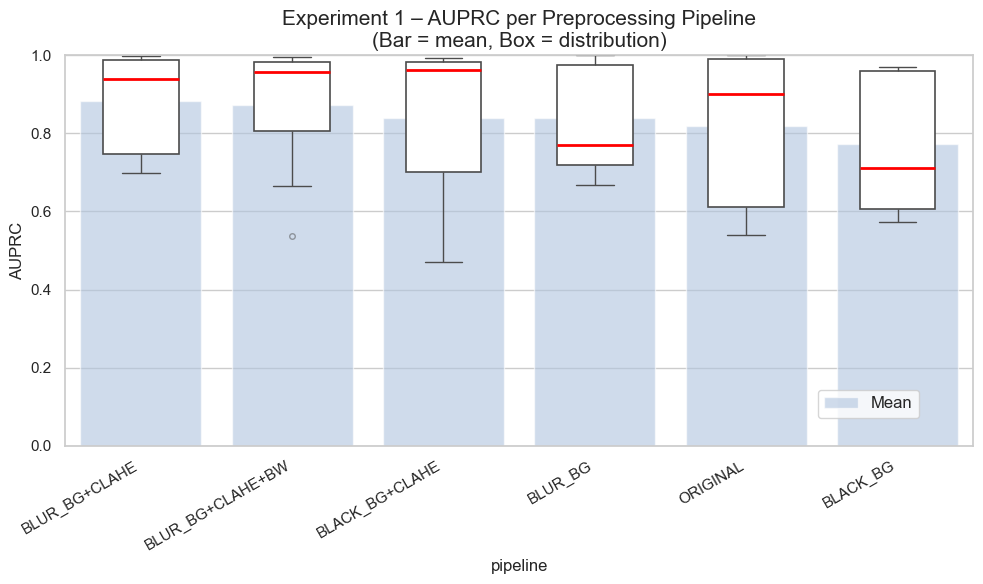

In [ ]:
RESULTS_DIR = "results_experiment1"
METRICS = ["auprc", "f1", "recall", "precision"]

pipeline_mapping = {
    "original_inner_folds":        "ORIGINAL",
    "black_inner_folds":           "BLACK_BG",
    "blackclahe_inner_folds":      "BLACK_BG+CLAHE",
    "blur_inner_folds":            "BLUR_BG",
    "blurclahe_inner_seed123":     "BLUR_BG+CLAHE",
    "blurclahebw_inner_folds":     "BLUR_BG+CLAHE+BW",
}

pipeline_order = [
    "ORIGINAL",
    "BLACK_BG",
    "BLACK_BG+CLAHE",
    "BLUR_BG",
    "BLUR_BG+CLAHE",
    "BLUR_BG+CLAHE+BW"
]

#Load results
rows = []
for path in glob.glob(f"{RESULTS_DIR}/**/val_metrics.json", recursive=True):
    with open(path, "r") as f:
        m = json.load(f)
    parts = path.split(os.sep)
    raw = parts[1]
    if raw not in pipeline_mapping:
        continue
    pipeline = pipeline_mapping[raw]
    seed = int(parts[3].replace("seed",""))
    entry = {"pipeline": pipeline, "seed": seed}
    for met in METRICS:
        entry[met] = m.get(met, np.nan)
    rows.append(entry)

df = pd.DataFrame(rows)
df[METRICS] = df[METRICS].apply(pd.to_numeric, errors="coerce")
df["pipeline"] = pd.Categorical(df["pipeline"], categories=pipeline_order, ordered=True)
df = df.sort_values("pipeline")

#Table: compute mean ± std
summary = df.groupby("pipeline")[METRICS].agg(["mean", "std"]).reset_index()
summary.columns = ["pipeline"] + [f"{m}_{stat}" for m in METRICS for stat in ["mean", "std"]]
summary = summary.sort_values("auprc_mean", ascending=False)

for met in METRICS:
    summary[f"{met}_fmt"] = summary.apply(
        lambda row: f"{row[f'{met}_mean']:.3f} ± {row[f'{met}_std']:.3f}",
        axis=1
    )

table = summary[[
    "pipeline",
    "auprc_fmt",
    "f1_fmt",
    "recall_fmt",
    "precision_fmt"
]]
table.columns = [
    "Pipeline",
    "AUPRC (mean ± std)",
    "F1-score (mean ± std)",
    "Recall (mean ± std)",
    "Precision (mean ± std)"
]

table.to_csv("exp1_results_table.csv", index=False)
print("\n=== Experiment 1 Results Table ===\n")

print(table.to_string(index=False))
# Save LaTeX table 
latex_table = table.to_latex(
    index=False,
    escape=False,
    column_format="lcccc",    
    bold_rows=False,
    longtable=False,
    multicolumn=False
)

with open("exp1_results_table.tex", "w") as f:
    f.write(latex_table)

print("\nLaTeX table saved as exp1_results_table.tex")


metric = "auprc"
mean_vals = df.groupby("pipeline")[metric].mean().reindex(pipeline_order)
std_vals  = df.groupby("pipeline")[metric].std().reindex(pipeline_order)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
# Sort pipelines by mean AUPRC
mean_vals = df.groupby("pipeline")[metric].mean()
pipelines_sorted = mean_vals.sort_values(ascending=False).index.tolist()


plt.bar(
    x = np.arange(len(pipelines_sorted)),
    height = mean_vals[pipelines_sorted],
    color = "lightsteelblue",
    alpha = 0.6,
    label = "Mean"
)

sns.boxplot(
    data=df,
    x="pipeline",
    y=metric,
    order=pipelines_sorted,
    width = 0.5,
    patch_artist=True,
    boxprops={"facecolor":"white","linewidth":1.2},
    medianprops={"color":"red","linewidth":2,"solid_capstyle":"butt"},
    whiskerprops={"linewidth":1.0},
    flierprops={"marker":"o","markersize":4,"alpha":0.5}
)


plt.xticks(rotation=30, ha="right")

plt.ylabel("AUPRC")
plt.ylim(0, 1)
plt.title("Experiment 1 – AUPRC per Preprocessing Pipeline\n(Bar = mean, Box = distribution)", fontsize=15)

plt.legend(
    loc='lower right',
    bbox_to_anchor=(0.95, 0.05),  
    frameon=True,
    fontsize='medium'
)

plt.tight_layout()
plt.savefig("exp1_AUPRC_overlay.png", dpi=300)
plt.show()



# Create plots/tables for experiment 2


=== Median Table for Seeds ===
cv_seed    auprc       f1   recall  precision
      0 0.911218 0.793388 0.940000   0.734375
    123 0.938903 0.790323 0.970000   0.875000
     26 0.968004 0.809917 0.950000   0.809524
     42 0.946799 0.823529 0.941176   0.882353
     79 0.933305 0.870370 0.920000   0.796610

=== Summary Table for Seeds (sorted by AUPRC) ===
Seed AUPRC (mean ± std) F1 (mean ± std) RECALL (mean ± std) PRECISION (mean ± std)
 123      0.883 ± 0.122   0.830 ± 0.123       0.862 ± 0.162          0.821 ± 0.138
  26      0.867 ± 0.145   0.813 ± 0.151       0.850 ± 0.192          0.802 ± 0.145
  79      0.861 ± 0.133   0.828 ± 0.129       0.904 ± 0.096          0.777 ± 0.170
  42      0.858 ± 0.158   0.798 ± 0.169       0.835 ± 0.198          0.793 ± 0.174
   0      0.813 ± 0.192   0.799 ± 0.163       0.871 ± 0.151          0.763 ± 0.199


C:\Users\myria\AppData\Local\Temp\ipykernel_83964\1209444665.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("cv_seed")[METRICS].agg(["mean","std"]).reset_index()
C:\Users\myria\AppData\Local\Temp\ipykernel_83964\1209444665.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_vals = df.groupby("cv_seed")[metric].mean().loc[seed_order]
C:\Users\myria\AppData\Local\Temp\ipykernel_83964\1209444665.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

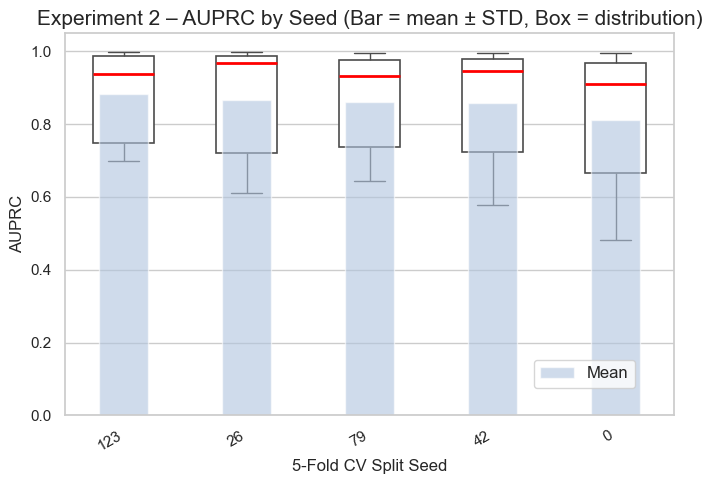

C:\Users\myria\AppData\Local\Temp\ipykernel_83964\1209444665.py:95: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='auprc', index='cv_seed', columns='fold', aggfunc='mean')


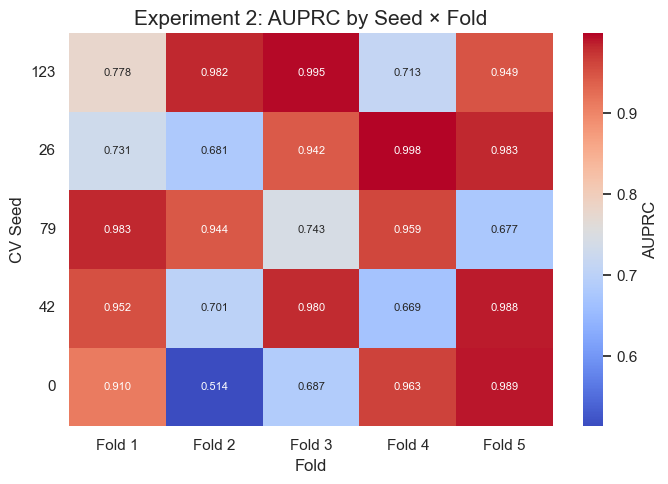

In [7]:
RESULTS_DIR = "results_experiment2"
METRICS = ["auprc", "f1", "recall", "precision"]


rows = []
for path in glob.glob(f"{RESULTS_DIR}/**/val_metrics.json", recursive=True):
    with open(path, "r") as f:
        m = json.load(f)
    parts = path.split(os.sep)
    split = parts[1]                  # e.g. "blurclahe_inner_seed123"
    cv_seed = split.split("seed")[-1]
    fold = parts[2]                   # e.g. "fold_0"
    entry = {"cv_seed": cv_seed, "fold": fold}
    for met in METRICS:
        entry[met] = m.get(met, np.nan)
    rows.append(entry)

df = pd.DataFrame(rows)
df[METRICS] = df[METRICS].apply(pd.to_numeric, errors="coerce")

median_vals = df.groupby("cv_seed")[METRICS].median().reset_index()
print("\n=== Median Table for Seeds ===")
print(median_vals.to_string(index=False))

# Sort seeds by mean AUPRC
metric = "auprc"
mean_vals_all = df.groupby("cv_seed")[metric].mean()
seed_order = mean_vals_all.sort_values(ascending=False).index.tolist()
df["cv_seed"] = pd.Categorical(df["cv_seed"], categories=seed_order, ordered=True)

# Summary table by seed
summary = df.groupby("cv_seed")[METRICS].agg(["mean","std"]).reset_index()
summary = summary.set_index("cv_seed").loc[seed_order].reset_index()
summary.columns = ["cv_seed"] + [f"{m}_{s}" for m, s in summary.columns if s in ["mean","std"]]

for m in METRICS:
    summary[f"{m}_fmt"] = summary.apply(
        lambda r: f"{r[f'{m}_mean']:.3f} ± {r[f'{m}_std']:.3f}", axis=1
    )

table_all_seeds = summary[["cv_seed"] + [f"{m}_fmt" for m in METRICS]]
table_all_seeds.columns = ["Seed"] + [f"{m.upper()} (mean ± std)" for m in METRICS]

print("\n=== Summary Table for Seeds (sorted by AUPRC) ===")
print(table_all_seeds.to_string(index=False))
table_all_seeds.to_csv("exp2_seed_summary_table.csv", index=False)

# Combined plot: average ± std + distribution per seed 
plt.figure(figsize=(7,5))
sns.set_theme(style="whitegrid")

# Boxplot (distribution)
sns.boxplot(
    data=df,
    x="cv_seed",
    y=metric,
    order=seed_order,
    width=0.5,
    showcaps=True,
    patch_artist=True,
    boxprops={"facecolor":"white","linewidth":1.2},
    medianprops={"color":"red","linewidth":2, "solid_capstyle":"butt"},
    whiskerprops={"linewidth":1.0},
    flierprops={"marker":"o","markersize":4,"alpha":0.5}
)

# Bar plot (mean ± std)
mean_vals = df.groupby("cv_seed")[metric].mean().loc[seed_order]
std_vals  = df.groupby("cv_seed")[metric].std().loc[seed_order]
plt.bar(
    x=np.arange(len(seed_order)),
    height=mean_vals.values,
    width=0.4,
    color="lightsteelblue",
    alpha=0.6,
    label="Mean",
    zorder=2
)

plt.xticks(ticks=np.arange(len(seed_order)), labels=seed_order, rotation=30, ha="right")
plt.xlabel("5-Fold CV Split Seed")
plt.ylabel(metric.upper())
plt.title(f"Experiment 2 – {metric.upper()} by Seed (Bar = mean ± STD, Box = distribution)",fontsize=15)
plt.legend(
    loc='lower right',
    bbox_to_anchor=(0.95, 0.05),  
    frameon=True,
    fontsize='medium'
)
plt.tight_layout()
plt.savefig("exp2_AUPRC_seed_combined.png", dpi=300)
plt.show()

# Heatmap: AUPRC by seed × fold
pivot = df.pivot_table(values='auprc', index='cv_seed', columns='fold', aggfunc='mean')
pivot = pivot.loc[seed_order]

plt.figure(figsize=(7, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",          
    linewidths=0,             
    cbar_kws={"label": "AUPRC"},
    annot_kws={"fontsize": 8}
)

plt.title("Experiment 2: AUPRC by Seed × Fold",
          fontsize=15)

plt.xlabel("Fold", fontsize=12)
plt.ylabel("CV Seed", fontsize=12)


plt.xticks(
    ticks=np.arange(len(pivot.columns)) + 0.5,
    labels=[f"Fold {i+1}" for i in range(len(pivot.columns))],
    rotation=0
)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("exp2_heatmap_seed_fold.png", dpi=300, bbox_inches="tight")
plt.show()





# Characteristics of selected split

In [ ]:
df = pd.read_csv("./blurclahe_data_folds/blurclahe_inner_seed79/sequence_fold_manifest_inner.csv")

# Create a simplified station identifier: part before first underscore
df["station_base"] = df["station"].apply(lambda x: x.split("_")[0])

fold_stats = df.groupby("fold").agg(
    sequences=("station", "count"),
    patches_total=("n_patches", "sum"),
    defective_patches=("n_defective", "sum"),
    stations=("station_base", "nunique")
).reset_index()

fold_stats["pct_defective"] = 100 * fold_stats["defective_patches"] / fold_stats["patches_total"]

print(fold_stats)

fold_stats.to_csv("exp2_seed79_fold_characteristics.csv", index=False)

print("\nExported: exp2_seed79_fold_characteristics.csv")



   fold  sequences  patches_total  defective_patches  stations  pct_defective
0     0         11            290                100        10      34.482759
1     1         12            210                 92         9      43.809524
2     2         13            220                 42         8      19.090909
3     3         11            290                 49         9      16.896552
4     4         11            290                 42         9      14.482759

Exported: exp2_seed79_fold_characteristics.csv
